In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEMOVO.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [11]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

In [12]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [13]:
print(gender_predictions)

[[9.9875969e-01]
 [9.9793863e-01]
 [9.9840587e-01]
 [9.9657059e-01]
 [9.9734259e-01]
 [9.9890888e-01]
 [9.9837410e-01]
 [9.9832249e-01]
 [9.9826175e-01]
 [9.9827796e-01]
 [9.9887311e-01]
 [9.9871707e-01]
 [9.9882758e-01]
 [9.9893355e-01]
 [9.9897659e-01]
 [9.9801260e-01]
 [9.9888933e-01]
 [9.9868536e-01]
 [9.9918228e-01]
 [9.9909079e-01]
 [9.9930561e-01]
 [9.9900162e-01]
 [9.9880624e-01]
 [9.9848449e-01]
 [9.9904728e-01]
 [9.9847203e-01]
 [9.9892616e-01]
 [9.9817097e-01]
 [9.9795425e-01]
 [9.9887365e-01]
 [9.9916810e-01]
 [9.9916351e-01]
 [9.9740446e-01]
 [9.9933785e-01]
 [9.9927926e-01]
 [9.9923313e-01]
 [9.9915284e-01]
 [9.9899447e-01]
 [9.9901319e-01]
 [9.9928236e-01]
 [9.9945617e-01]
 [9.9929661e-01]
 [9.9920279e-01]
 [9.9816060e-01]
 [9.9926168e-01]
 [9.9490869e-01]
 [9.9894917e-01]
 [9.9896592e-01]
 [9.9919677e-01]
 [9.9900955e-01]
 [9.9902725e-01]
 [9.9901509e-01]
 [9.9859440e-01]
 [9.9934071e-01]
 [9.9842125e-01]
 [9.9905026e-01]
 [9.9816000e-01]
 [9.9572623e-01]
 [9.9881679e-0

In [23]:
male_rows = gender_predictions.flatten() < 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} male samples.")

Filtered dataset contains 293 male samples.


In [24]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
294,-225.834305,83.962433,-5.286817,35.728619,-13.078013,17.963274,-14.742523,4.787130,-3.795607,9.062120,...,33.802033,0.018696,-0.009439,-0.011013,-0.002207,0.014388,0.001134,2,1,4
295,-248.242477,88.256699,2.077917,48.205994,-14.475659,10.191969,-9.108829,11.997128,-4.937069,9.115414,...,36.425106,-0.046464,-0.000673,-0.018350,0.024076,-0.030521,-0.010057,2,1,4
296,-288.580505,113.707069,-4.207919,36.642605,-7.948632,9.709131,-5.470535,5.543427,-0.030859,12.137795,...,34.574195,0.012381,-0.029587,-0.049667,-0.048555,-0.004218,0.019347,2,1,4
297,-264.005371,79.057182,-11.777345,39.176647,-14.728073,30.268671,-1.693096,4.519373,-3.846275,14.705531,...,34.959960,0.004540,0.010262,-0.001896,0.026106,-0.010619,0.014993,2,1,4
298,-319.776733,82.874512,-2.986594,41.945034,-8.119583,26.139738,0.383493,3.180753,-3.732891,11.955462,...,34.708427,-0.009257,-0.019991,0.067884,-0.045997,0.002260,0.011251,2,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [25]:
data.iloc[:,-3] == 1

0       True
1       True
2       True
3       True
4       True
       ...  
583    False
584    False
585    False
586    False
587    False
Name: gender, Length: 588, dtype: bool

In [26]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [27]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
294,-225.834305,83.962433,-5.286817,35.728619,-13.078013,17.963274,-14.742523,4.787130,-3.795607,9.062120,...,13.788023,16.202099,16.689351,33.802033,0.018696,-0.009439,-0.011013,-0.002207,0.014388,0.001134
295,-248.242477,88.256699,2.077917,48.205994,-14.475659,10.191969,-9.108829,11.997128,-4.937069,9.115414,...,14.467161,15.449994,17.459077,36.425106,-0.046464,-0.000673,-0.018350,0.024076,-0.030521,-0.010057
296,-288.580505,113.707069,-4.207919,36.642605,-7.948632,9.709131,-5.470535,5.543427,-0.030859,12.137795,...,14.419935,16.330941,18.172192,34.574195,0.012381,-0.029587,-0.049667,-0.048555,-0.004218,0.019347
297,-264.005371,79.057182,-11.777345,39.176647,-14.728073,30.268671,-1.693096,4.519373,-3.846275,14.705531,...,13.489356,16.934286,15.906022,34.959960,0.004540,0.010262,-0.001896,0.026106,-0.010619,0.014993
298,-319.776733,82.874512,-2.986594,41.945034,-8.119583,26.139738,0.383493,3.180753,-3.732891,11.955462,...,13.730269,16.036330,17.712544,34.708427,-0.009257,-0.019991,0.067884,-0.045997,0.002260,0.011251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,16.535757,15.881800,18.443654,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,16.113687,16.514813,18.799787,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,14.285399,16.010688,18.472471,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,14.503504,15.854289,17.343597,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469


In [28]:
y

294    1
295    1
296    1
297    1
298    1
      ..
583    7
584    7
585    7
586    7
587    7
Name: labels, Length: 293, dtype: int64

In [29]:
X_speaker

294    4
295    4
296    4
297    4
298    4
      ..
583    6
584    6
585    6
586    6
587    6
Name: speaker, Length: 293, dtype: int64

In [30]:
X.shape, y.shape

((293, 193), (293,))

In [31]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [32]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
379,-473.045288,53.226933,6.553693,49.558846,12.120684,19.048349,-7.448148,13.915257,1.123230,4.839060,...,13.827561,16.023941,15.595256,33.644470,-0.031703,0.010838,-0.058810,-0.009544,-0.002939,-0.013653
555,-401.126343,108.656075,-14.425789,15.860630,-16.299601,3.397458,-8.811973,4.896761,-15.697859,2.685100,...,16.403250,16.253721,19.286320,34.708102,-0.005951,0.028285,0.045162,0.101023,-0.011690,0.017166
340,-297.818359,79.029587,2.171455,35.510773,-1.513043,25.599234,-10.156668,2.467828,-3.063411,-4.880069,...,13.943135,16.088667,16.969553,35.725180,0.026572,-0.022727,0.037276,0.026800,0.010819,-0.002260
471,-359.475555,128.459717,6.705029,25.363127,-1.610091,4.884843,-17.698799,22.006542,-7.277613,-0.064891,...,16.200448,16.408151,17.240414,34.874436,0.030348,-0.054422,-0.035739,-0.061891,0.013624,0.033254
438,-330.407349,81.656845,-2.846666,20.971577,0.114539,34.684555,-17.840517,-2.804314,-11.987220,2.868062,...,16.427401,18.598014,17.333141,35.198632,-0.050054,0.003494,-0.009743,-0.066578,0.015853,0.002263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483,-452.896301,105.092400,14.654901,46.965553,2.764024,-4.706769,-11.466007,27.487827,-4.443110,3.852906,...,17.682854,16.169113,17.665412,33.079512,-0.020896,0.036944,-0.048509,0.022389,-0.017108,-0.026029
366,-232.955002,71.244987,-9.745038,30.694834,-1.745239,18.551792,-7.097457,0.965884,-8.153107,13.733312,...,14.702219,16.347526,16.779713,35.525359,-0.010536,0.029192,0.013123,-0.030376,-0.005267,-0.017747
401,-411.178009,115.658463,-9.709141,25.695103,9.495248,17.243771,-8.666966,4.931623,-4.182792,8.655084,...,15.802761,18.585487,17.936297,33.013891,-0.013325,-0.023234,-0.060386,-0.138147,0.006659,-0.019446
565,-415.438660,97.701500,6.539171,37.497177,-7.827160,-5.104220,3.481432,8.109325,-14.200720,11.841024,...,16.100291,16.561144,19.920503,33.891182,0.002476,0.008427,0.033056,-0.018273,0.000510,-0.007005


In [33]:
X_speaker

379    4
555    6
340    4
471    5
438    5
      ..
483    5
366    4
401    5
565    6
397    5
Name: speaker, Length: 293, dtype: int64

In [34]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [35]:
y1

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(293, 7))

In [36]:
X.shape, y1.shape

((293, 193), (293, 7))

In [37]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [38]:
X2.shape, X2_speaker.shape, y2.shape

((293, 193), (293,), (293,))

In [39]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [40]:
import random, numpy as np
from keras import optimizers
kfold=3
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [41]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-473.045288,53.226933,6.553693,49.558846,12.120684,19.048349,-7.448148,13.915257,1.123230,4.839060,...,13.827561,16.023941,15.595256,33.644470,-0.031703,0.010838,-0.058810,-0.009544,-0.002939,-0.013653
1,-401.126343,108.656075,-14.425789,15.860630,-16.299601,3.397458,-8.811973,4.896761,-15.697859,2.685100,...,16.403250,16.253721,19.286320,34.708102,-0.005951,0.028285,0.045162,0.101023,-0.011690,0.017166
2,-297.818359,79.029587,2.171455,35.510773,-1.513043,25.599234,-10.156668,2.467828,-3.063411,-4.880069,...,13.943135,16.088667,16.969553,35.725180,0.026572,-0.022727,0.037276,0.026800,0.010819,-0.002260
3,-359.475555,128.459717,6.705029,25.363127,-1.610091,4.884843,-17.698799,22.006542,-7.277613,-0.064891,...,16.200448,16.408151,17.240414,34.874436,0.030348,-0.054422,-0.035739,-0.061891,0.013624,0.033254
4,-330.407349,81.656845,-2.846666,20.971577,0.114539,34.684555,-17.840517,-2.804314,-11.987220,2.868062,...,16.427401,18.598014,17.333141,35.198632,-0.050054,0.003494,-0.009743,-0.066578,0.015853,0.002263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,-452.896301,105.092400,14.654901,46.965553,2.764024,-4.706769,-11.466007,27.487827,-4.443110,3.852906,...,17.682854,16.169113,17.665412,33.079512,-0.020896,0.036944,-0.048509,0.022389,-0.017108,-0.026029
289,-232.955002,71.244987,-9.745038,30.694834,-1.745239,18.551792,-7.097457,0.965884,-8.153107,13.733312,...,14.702219,16.347526,16.779713,35.525359,-0.010536,0.029192,0.013123,-0.030376,-0.005267,-0.017747
290,-411.178009,115.658463,-9.709141,25.695103,9.495248,17.243771,-8.666966,4.931623,-4.182792,8.655084,...,15.802761,18.585487,17.936297,33.013891,-0.013325,-0.023234,-0.060386,-0.138147,0.006659,-0.019446
291,-415.438660,97.701500,6.539171,37.497177,-7.827160,-5.104220,3.481432,8.109325,-14.200720,11.841024,...,16.100291,16.561144,19.920503,33.891182,0.002476,0.008427,0.033056,-0.018273,0.000510,-0.007005


In [42]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,4
1,6
2,4
3,5
4,5
...,...
288,5
289,4
290,5
291,6


In [43]:
speakers = X_speaker.unique()
speakers

array([4, 6, 5])

In [44]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,4
1,6
2,4
3,5
4,5
...,...
288,5
289,4
290,5
291,6


In [45]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-473.045288,53.226933,6.553693,49.558846,12.120684,19.048349,-7.448148,13.915257,1.123230,4.839060,...,16.023941,15.595256,33.644470,-0.031703,0.010838,-0.058810,-0.009544,-0.002939,-0.013653,4
1,-401.126343,108.656075,-14.425789,15.860630,-16.299601,3.397458,-8.811973,4.896761,-15.697859,2.685100,...,16.253721,19.286320,34.708102,-0.005951,0.028285,0.045162,0.101023,-0.011690,0.017166,6
2,-297.818359,79.029587,2.171455,35.510773,-1.513043,25.599234,-10.156668,2.467828,-3.063411,-4.880069,...,16.088667,16.969553,35.725180,0.026572,-0.022727,0.037276,0.026800,0.010819,-0.002260,4
3,-359.475555,128.459717,6.705029,25.363127,-1.610091,4.884843,-17.698799,22.006542,-7.277613,-0.064891,...,16.408151,17.240414,34.874436,0.030348,-0.054422,-0.035739,-0.061891,0.013624,0.033254,5
4,-330.407349,81.656845,-2.846666,20.971577,0.114539,34.684555,-17.840517,-2.804314,-11.987220,2.868062,...,18.598014,17.333141,35.198632,-0.050054,0.003494,-0.009743,-0.066578,0.015853,0.002263,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,-452.896301,105.092400,14.654901,46.965553,2.764024,-4.706769,-11.466007,27.487827,-4.443110,3.852906,...,16.169113,17.665412,33.079512,-0.020896,0.036944,-0.048509,0.022389,-0.017108,-0.026029,5
289,-232.955002,71.244987,-9.745038,30.694834,-1.745239,18.551792,-7.097457,0.965884,-8.153107,13.733312,...,16.347526,16.779713,35.525359,-0.010536,0.029192,0.013123,-0.030376,-0.005267,-0.017747,4
290,-411.178009,115.658463,-9.709141,25.695103,9.495248,17.243771,-8.666966,4.931623,-4.182792,8.655084,...,18.585487,17.936297,33.013891,-0.013325,-0.023234,-0.060386,-0.138147,0.006659,-0.019446,5
291,-415.438660,97.701500,6.539171,37.497177,-7.827160,-5.104220,3.481432,8.109325,-14.200720,11.841024,...,16.561144,19.920503,33.891182,0.002476,0.008427,0.033056,-0.018273,0.000510,-0.007005,6


In [46]:
# Get top 5 speakers with the most data

speaker_counts = X_combined['speaker'].value_counts()
selected_speakers = speaker_counts.head(3).index.to_numpy()

print("Selected speakers:", selected_speakers)

Selected speakers: [6 5 4]


In [47]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=291
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='emovo_speaker_male'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")
    
    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 6
Train speakers: [4 5]
No overlap in fold 0.
Top 125 features: [ 49  93   0  41   8  31   2  58  48 109] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.2205 - loss: 2.0467 - val_accuracy: 0.1429 - val_loss: 1.9463
Epoch 2/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3949 - loss: 1.5791 - val_accuracy: 0.1429 - val_loss: 1.9494
Epoch 3/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4821 - loss: 1.4553 - val_accuracy: 0.1429 - val_loss: 1.9530
Epoch 4/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5744 - loss: 1.3215 - val_accuracy: 0.1429 - val_loss: 1.9570
Epoch 5/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5487 - loss: 1.2969 - val_accuracy: 0.1429 - val_loss: 1.9594
Epoch 6/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6256 - loss: 1.1641 - val_accuracy: 0.1429 - val_loss: 1.9613
Epoch 7/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7179 - loss: 1.0584 - val_accuracy: 0.1429 - val_loss: 1.9627
Epoch 8/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7487 - loss: 1.0200 - val_accuracy: 0.1429 - val_loss: 1.9651
Epoc

Fold 0 Test Accuracy: 0.3061

===== Fold 1 =====
Test speaker: 5
Train speakers: [4 6]
No overlap in fold 1.
Top 125 features: [35 62  1 56 48  9  5 91  0  7] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2615 - loss: 1.9741 - val_accuracy: 0.2347 - val_loss: 1.9117
Epoch 2/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4051 - loss: 1.5891 - val_accuracy: 0.2041 - val_loss: 1.9209
Epoch 3/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4462 - loss: 1.4692 - val_accuracy: 0.1735 - val_loss: 1.9274
Epoch 4/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5026 - loss: 1.3738 - val_accuracy: 0.1735 - val_loss: 1.9343
Epoch 5/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5795 - loss: 1.2748 - val_accuracy: 0.1633 - val_loss: 1.9393
Epoch 6/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6154 - loss: 1.2221 - val_accuracy: 0.1429 - val_loss: 1.9448
Epoch 7/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6667 - loss: 1.1582 - val_accuracy: 0.1531 - val_loss: 1.9476
Epoch 8/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6667 - loss: 1.1421 - val_accuracy: 0.1429 - val_loss: 1.9525
Epoc

Fold 1 Test Accuracy: 0.4796

===== Fold 2 =====
Test speaker: 4
Train speakers: [5 6]
No overlap in fold 2.
Top 125 features: [  2  82   1  26  18  29  81  11 177  83] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2449 - loss: 1.9800 - val_accuracy: 0.0928 - val_loss: 1.8994
Epoch 2/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4184 - loss: 1.6112 - val_accuracy: 0.1340 - val_loss: 1.8957
Epoch 3/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5204 - loss: 1.3960 - val_accuracy: 0.1959 - val_loss: 1.9041
Epoch 4/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5765 - loss: 1.3410 - val_accuracy: 0.1856 - val_loss: 1.9175
Epoch 5/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6480 - loss: 1.2149 - val_accuracy: 0.1959 - val_loss: 1.9282
Epoch 6/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6837 - loss: 1.1180 - val_accuracy: 0.1856 - val_loss: 1.9438
Epoch 7/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7602 - loss: 1.0406 - val_accuracy: 0.1753 - val_loss: 1.9580
Epoch 8/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7194 - loss: 1.0294 - val_accuracy: 0.1856 - val_loss: 1.9684
Epoc

Fold 2 Test Accuracy: 0.4124

===== Cross-validation results =====
Fold 0: Loss=1.9025, Accuracy=0.3061
Fold 1: Loss=1.6187, Accuracy=0.4796
Fold 2: Loss=2.4664, Accuracy=0.4124

Average accuracy: 0.3994


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'emovo_speaker_male'
num_folds = 3
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)
mean_acc = np.mean(accuracies)

print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")

2025-11-10 15:52:52.444938: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 15:52:52.476358: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 15:52:53.149446: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 30.61%
Fold 1: Accuracy = 47.96%
Fold 2: Accuracy = 41.24%

Mean Accuracy: 39.94%
SD Accuracy: 7.14
95% CI: [31.85%, 48.02%]


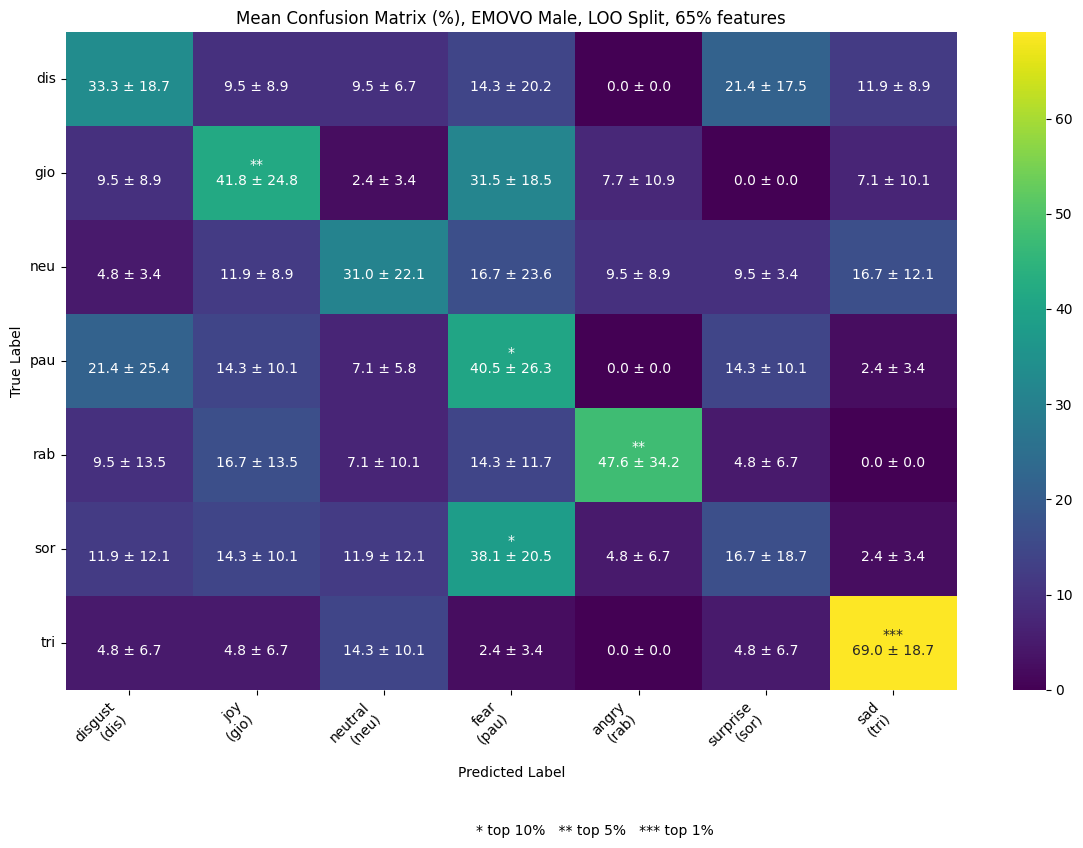

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_emovo_speaker_male.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"

y_list = ['dis', 'gio', 'neu', 'pau', 'rab', 'sor', 'tri']
x_list = ['disgust\n(dis)', 'joy\n(gio)', 'neutral\n(neu)','fear\n(pau)', 'angry\n(rab)', 'surprise\n(sor)', 'sad\n(tri)']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(x_list)) + 0.5)
ax.set_yticks(np.arange(len(y_list)) + 0.5)
ax.set_xticklabels(x_list, rotation=45, ha="right")
ax.set_yticklabels(y_list, rotation=0)

plt.title("Mean Confusion Matrix (%), EMOVO Male, LOO Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%",
            ha="center", fontsize=10)
plt.show()
